In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Bangalore.csv")

In [5]:
df

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium
0,30000000,3340,JP Nagar Phase 1,4,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
1,7888000,1045,Dasarahalli on Tumkur Road,2,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,4866000,1179,Kannur on Thanisandra Main Road,2,0,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
3,8358000,1675,Doddanekundi,3,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,6845000,1670,Kengeri,3,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6202,5364000,590,Chandapura,1,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
6203,8716000,1179,Kasavanahalli,2,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
6204,7373000,1143,Kasavanahalli,2,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
6205,4985000,1680,Kasavanahalli,3,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9


In [7]:
df = df.drop(columns=['BED','DiningTable','Sofa','TV','Wardrobe','Microwave'])


In [9]:
amenities_cols = [
    'MaintenanceStaff','Gymnasium','SwimmingPool','LandscapedGardens','JoggingTrack','RainWaterHarvesting','IndoorGames','ShoppingMall',
    'Intercom','SportsFacility','ATM','ClubHouse','School','24X7Security','PowerBackup','CarParking','StaffQuarter','Cafeteria','MultipurposeRoom',
    'Hospital','WashingMachine','Gasconnection','AC','Wifi',"Children'splayarea",'LiftAvailable','GolfCourse','Stadium'
]

df['Total_Amenities'] = df[amenities_cols].sum(axis=1)

In [11]:
df.drop(columns= amenities_cols, inplace= True)

In [13]:
df

,Price,Area,Location,No. of Bedrooms,Resale,VaastuCompliant,Total_Amenities
0,30000000,3340,JP Nagar Phase 1,4,0,0,14
1,7888000,1045,Dasarahalli on Tumkur Road,2,0,1,14
2,4866000,1179,Kannur on Thanisandra Main Road,2,0,0,9
3,8358000,1675,Doddanekundi,3,0,0,3
4,6845000,1670,Kengeri,3,0,0,16
...,...,...,...,...,...,...,...
6202,5364000,590,Chandapura,1,0,9,252
6203,8716000,1179,Kasavanahalli,2,0,9,252
6204,7373000,1143,Kasavanahalli,2,0,9,252
6205,4985000,1680,Kasavanahalli,3,0,9,252


In [15]:
#EDA

#Basic Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6207 entries, 0 to 6206
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Price            6207 non-null   int64 
 1   Area             6207 non-null   int64 
 2   Location         6207 non-null   object
 3   No. of Bedrooms  6207 non-null   int64 
 4   Resale           6207 non-null   int64 
 5   VaastuCompliant  6207 non-null   int64 
 6   Total_Amenities  6207 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 339.6+ KB


,Price,Area,No. of Bedrooms,Resale,VaastuCompliant,Total_Amenities
count,6.207000e+03,6207.000000,6207.000000,6207.000000,6207.000000,6207.000000
mean,1.058510e+07,1526.094248,2.556952,0.078782,6.311100,176.708394
std,1.410943e+07,764.845609,0.694300,0.269420,3.981513,111.245634
min,2.000000e+06,415.000000,1.000000,0.000000,0.000000,0.000000
25%,5.000000e+06,1110.000000,2.000000,0.000000,1.000000,17.000000
50%,7.368000e+06,1340.000000,3.000000,0.000000,9.000000,252.000000
75%,1.070000e+07,1662.500000,3.000000,0.000000,9.000000,252.000000
max,3.000000e+08,9900.000000,7.000000,1.000000,9.000000,252.000000


In [17]:
#Check Null Values
df.isnull().sum()

Price              0
Area               0
Location           0
No. of Bedrooms    0
Resale             0
VaastuCompliant    0
Total_Amenities    0
dtype: int64

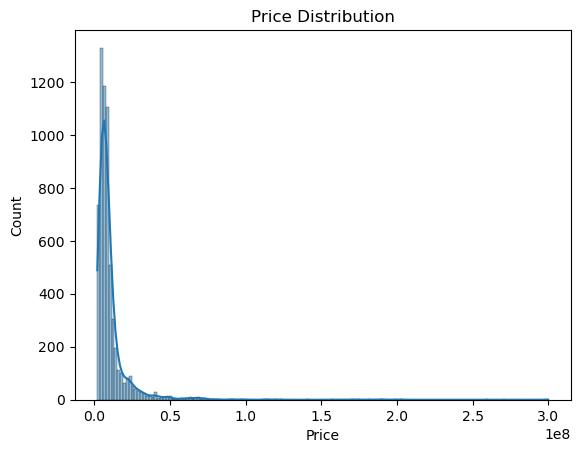

In [19]:
#Target Distribution
sns.histplot(df['Price'],kde=True)
plt.title("Price Distribution")
plt.show()

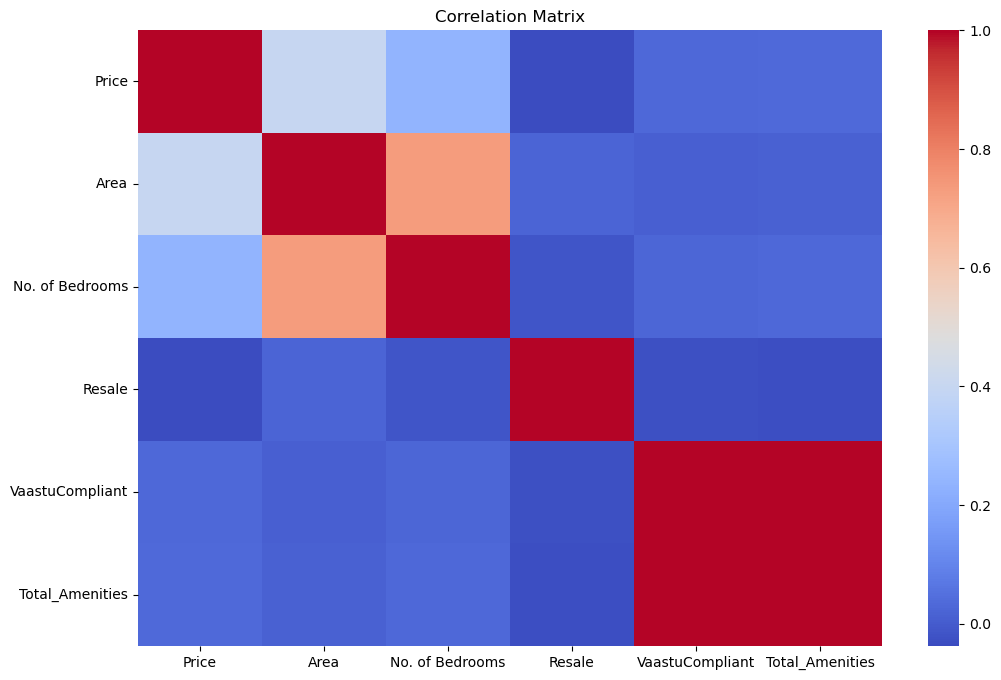

In [21]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

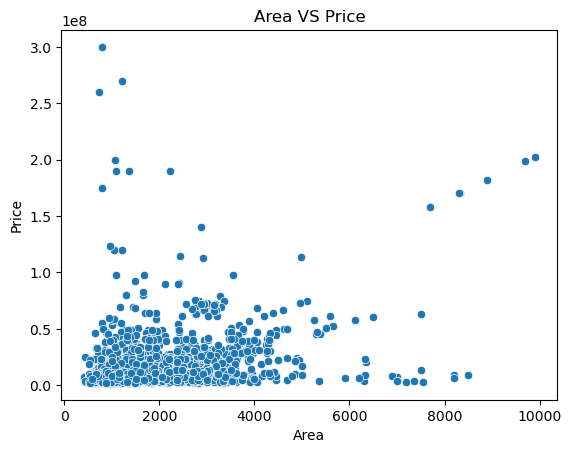

In [23]:
#Area Vs Price
sns.scatterplot(x='Area',y='Price',data=df)
plt.title('Area VS Price')
plt.show()

In [25]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[['Area']]
Y = df['Price']

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y,test_size=0.2,random_state=42)

lr = LinearRegression()
lr.fit(Xtrain,Ytrain)

Ypred = lr.predict(Xtest)

print("MAE: ",mean_absolute_error(Ytest,Ypred))
print("MSE: ",mean_squared_error(Ytest,Ypred))
print("R2 Score: ",r2_score(Ytest, Ypred))

MAE:  5216767.9831931535
MSE:  233939027885089.84
R2 Score:  0.1283845921331216


In [27]:
#Multiple Linear Regression 
X = df.drop('Price',axis=1)
Y = df['Price']

X = pd.get_dummies(X,drop_first=True)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y, test_size=0.2, random_state = 42)

mlr = LinearRegression()
mlr.fit(Xtrain,Ytrain)

Ypred = mlr.predict(Xtest)

print("MAE: ",mean_absolute_error(Ytest,Ypred))
print("MSE: ",mean_squared_error(Ytest,Ypred))
print("R2 Score: ",r2_score(Ytest,Ypred))

MAE:  4972007.788627448
MSE:  221852966595597.28
R2 Score:  0.17341511711897228


In [29]:
#Multiple Linear Regression Using PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y,test_size=0.2,random_state=42)

scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

pca = PCA(n_components = 0.95)
Xtrain_pca = pca.fit_transform(Xtrain_scaled)
Xtest_pca = pca.transform(Xtest_scaled)

model = LinearRegression()
model.fit(Xtrain_pca,Ytrain)

Ypred = model.predict(Xtest_pca)

print("PCA Regression R2:",r2_score(Ytest,Ypred))

PCA Regression R2: 0.1716742147246091


In [31]:
#Using Ridge And Lasso
from sklearn.linear_model import Lasso, Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(Xtrain_pca,Ytrain)
ridge_pred = ridge.predict(Xtest_pca)

lasso = Lasso(alpha=0.1)
lasso.fit(Xtrain_pca,Ytrain)
lasso_pred = lasso.predict(Xtest_pca)

print("R2 Score Ridge:",r2_score(Ytest,ridge_pred))
print("R2 Score Lasso:",r2_score(Ytest,lasso_pred))

R2 Score Ridge: 0.17167716952110945
R2 Score Lasso: 0.17167422175537628


In [33]:
#SVR model
from sklearn.svm import SVR

svr = SVR(kernel="rbf")
svr.fit(Xtrain_pca,Ytrain)

Ypred = svr.predict(Xtest_pca)

print("SVR R2:", r2_score(Ytest, Ypred))

SVR R2: -0.032406168511010636


In [35]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(Xtrain_pca,Ytrain)

Ypred = dt.predict(Xtest_pca)

print("Decision Tree R2:", r2_score(Ytest, Ypred))

Decision Tree R2: 0.03273384435238613


In [37]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(Xtrain_pca,Ytrain)

Ypred = rf.predict(Xtest_pca)

print("Random Forest R2:", r2_score(Ytest, Ypred))

Random Forest R2: 0.16618303959905212


In [39]:
#GridSearch CV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(Xtrain_pca, Ytrain)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 100}


In [45]:
#RandomizedSearch CV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50,300),
    'max_depth': randint(5,30),
}

random_search = RandomizedSearchCV(RandomForestRegressor(), param_dist, n_iter=10, cv=3,random_state=42)
random_search.fit(Xtrain_pca, Ytrain)

print("Best Params:", random_search.best_params_)

Best Params: {'max_depth': 12, 'n_estimators': 238}


In [59]:
#Comapre all models
models = {
    "Linear":lr,
    "MLR":mlr,
    "Ridge":ridge,
    "Lasso":lasso,
    "SVR":svr,
    "Decision Tree":dt,
    "Random Forest":rf,
}

for name,model in models.items():
    try:
        pred = model.predict(Xtest_pca)
        print(name," R2: ",r2_score(Ytest,pred))
    except:
        pass


C:\Users\aadia\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\aadia\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Ridge  R2:  0.17167716952110945
Lasso  R2:  0.17167422175537628
SVR  R2:  -0.032406168511010636
Decision Tree  R2:  0.03273384435238613
Random Forest  R2:  0.16618303959905212
